# **Importing the Dataset**

In [1]:
import pandas as pd

df = pd.read_csv('/content/insurance.csv')

# **Basic Data Exploration**

In [2]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# **Data Cleaning**

**Checking for Missing Values**

In [7]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


**Checking for Duplicate Values**

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df[(df.duplicated)]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [10]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.shape

(1337, 7)

**Data Validation**

In [13]:
df['age'].min(), df['age'].max()

(18, 64)

In [14]:
df['bmi'].min(), df['bmi'].max()

(15.96, 53.13)

# **Feature Engineering**

In [15]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)

<Axes: xlabel='bmi_category'>

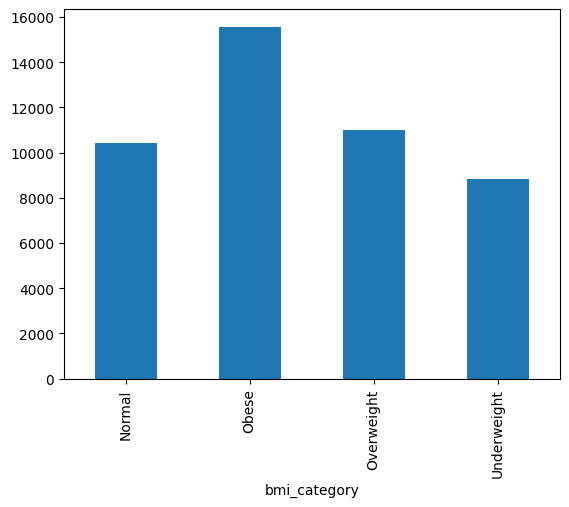

In [16]:
df.groupby('bmi_category')['charges'].mean().plot(kind='bar')

# **Exploratory Data Analysis**

**Numerical Analysis**

In [17]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64
bmi_category,object


**Age Distribution**

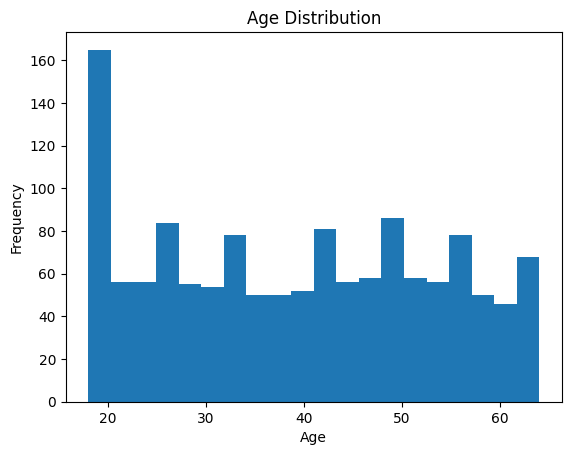

In [18]:
import matplotlib.pyplot as plt

plt.hist(df['age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**BMI Distribution**

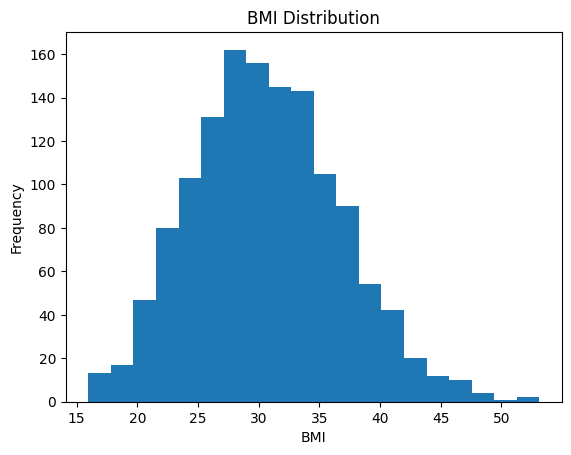

In [19]:
plt.hist(df['bmi'], bins=20)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

**Charges Distribution**

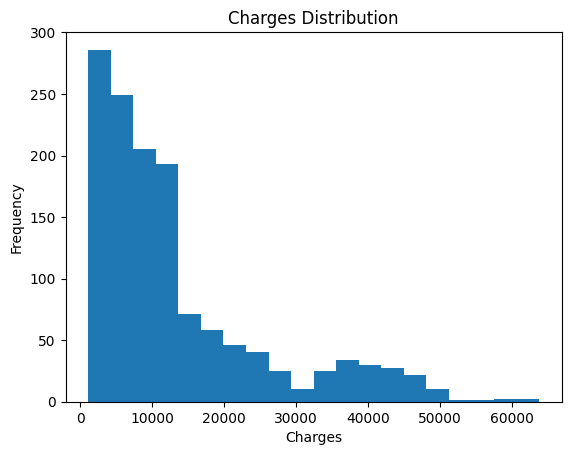

In [20]:
plt.hist(df['charges'], bins=20)
plt.title('Charges Distribution')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

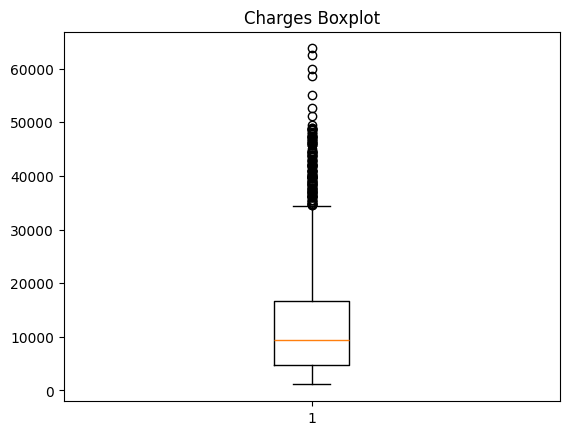

In [21]:
plt.boxplot(df['charges'])
plt.title('Charges Boxplot')
plt.show()

**Categorial Analysis**

**Smoker Vs Charges**

In [22]:
df.groupby('smoker')['charges'].mean()

,charges
smoker,
no,8440.660307
yes,32050.231832


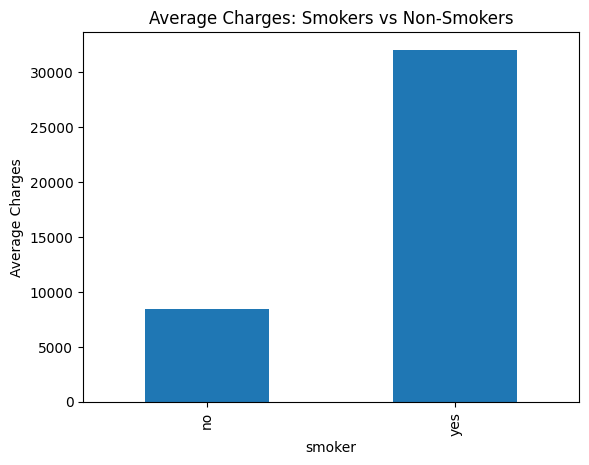

In [23]:
df.groupby('smoker')['charges'].mean().plot(kind='bar')
plt.title('Average Charges: Smokers vs Non-Smokers')
plt.ylabel('Average Charges')
plt.show()

**Sex Vs Charges**

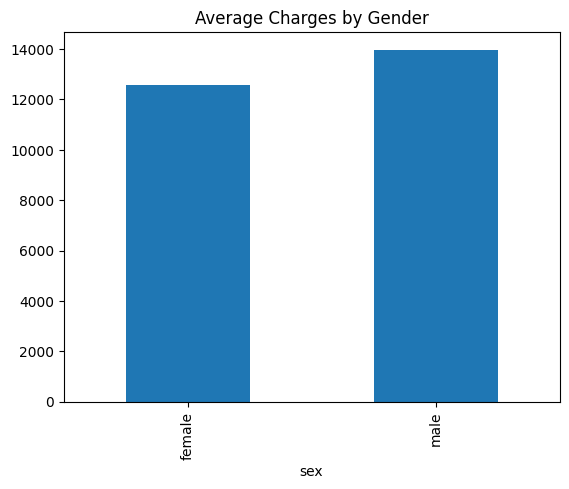

In [24]:
df.groupby('sex')['charges'].mean().plot(kind='bar')
plt.title('Average Charges by Gender')
plt.show()

**Region Vs Charges**

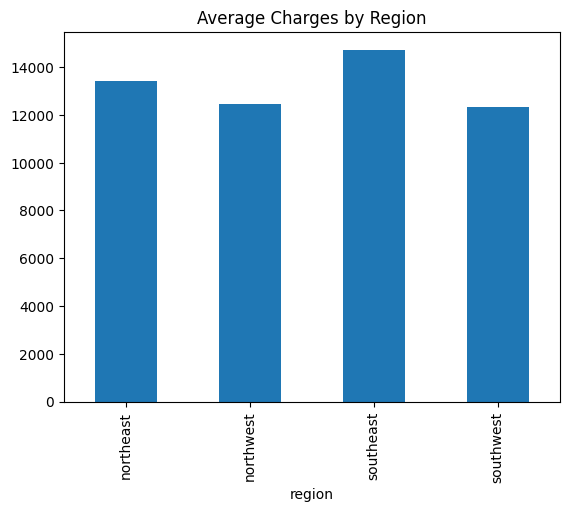

In [25]:
df.groupby('region')['charges'].mean().plot(kind='bar')
plt.title('Average Charges by Region')
plt.show()

**Relationship Analysis**

**Age Vs Charges**

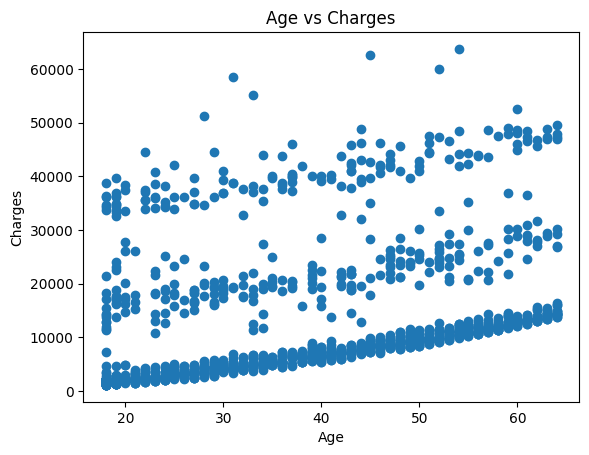

In [26]:
plt.scatter(df['age'], df['charges'])
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs Charges')
plt.show()

**BMI Vs Charges**

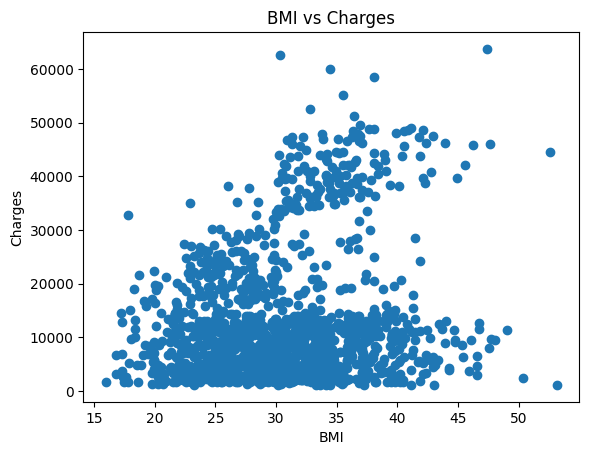

In [27]:
plt.scatter(df['bmi'], df['charges'])
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.title('BMI vs Charges')
plt.show()

In [28]:
df.to_csv('insurance_cleaned.csv', index=False)